# Mini-Project: Predicting Student Success (Pass/Fail)
**Dataset:** student-por.csv (Portuguese Language)
**University of Biskra – Department of Computer Science**
**Group:** Lyna Tatai · Medouekh Chaima Hibat Allah · Malak Boughougal

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, roc_curve
)
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
PALETTE = ['#4C72B0', '#DD8452']
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Task 1 – Data Exploration & Visualisation

In [2]:
# ── 1.1 Load the dataset ──────────────────────────────────────────────────────
df = pd.read_csv('student-por.csv', sep=';')
print(f'Shape: {df.shape}  ({df.shape[0]} students, {df.shape[1]} columns)')
df.head()

Shape: (649, 34)  (649 students, 34 columns)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,1


In [3]:
# ── 1.2 Structure overview ────────────────────────────────────────────────────
print('=== Column Types ===')
print(df.dtypes)
print('\n=== Descriptive Statistics (numerical) ===')
df.describe().round(2)

=== Column Types ===
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
pass          int64
dtype: object

=== Descriptive Statistics (numerical) ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91,0.85
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23,0.36
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00,1.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00,1.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00,1.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00,1.00


In [4]:
# ── 1.3 Missing values & duplicates ──────────────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
pass          0
dtype: int64

Duplicate rows: 0


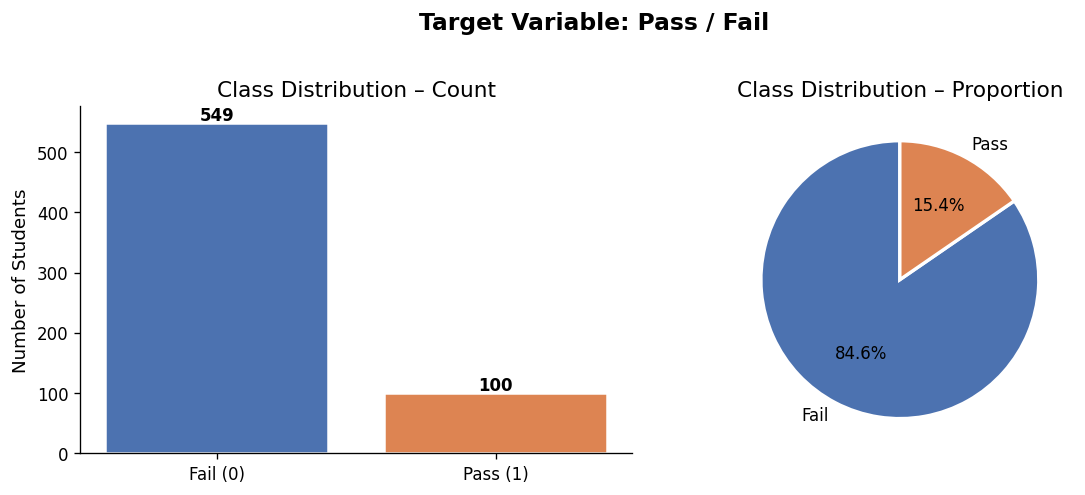

Fail: 100 (15.4%)   Pass: 549 (84.6%)
→ The dataset is imbalanced. SMOTE will be applied on the training set only.


In [5]:
# ── 1.4 Target class balance ──────────────────────────────────────────────────
counts = df['pass'].value_counts()
pcts   = df['pass'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Fail (0)', 'Pass (1)'], counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution – Count')
axes[0].set_ylabel('Number of Students')

axes[1].pie(counts.values, labels=['Fail', 'Pass'], autopct='%1.1f%%',
            colors=PALETTE, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution – Proportion')

plt.suptitle('Target Variable: Pass / Fail', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_class_balance.png', bbox_inches='tight')
plt.show()

print(f'Fail: {counts[0]} ({pcts[0]:.1f}%)   Pass: {counts[1]} ({pcts[1]:.1f}%)')
print('→ The dataset is imbalanced. SMOTE will be applied on the training set only.')

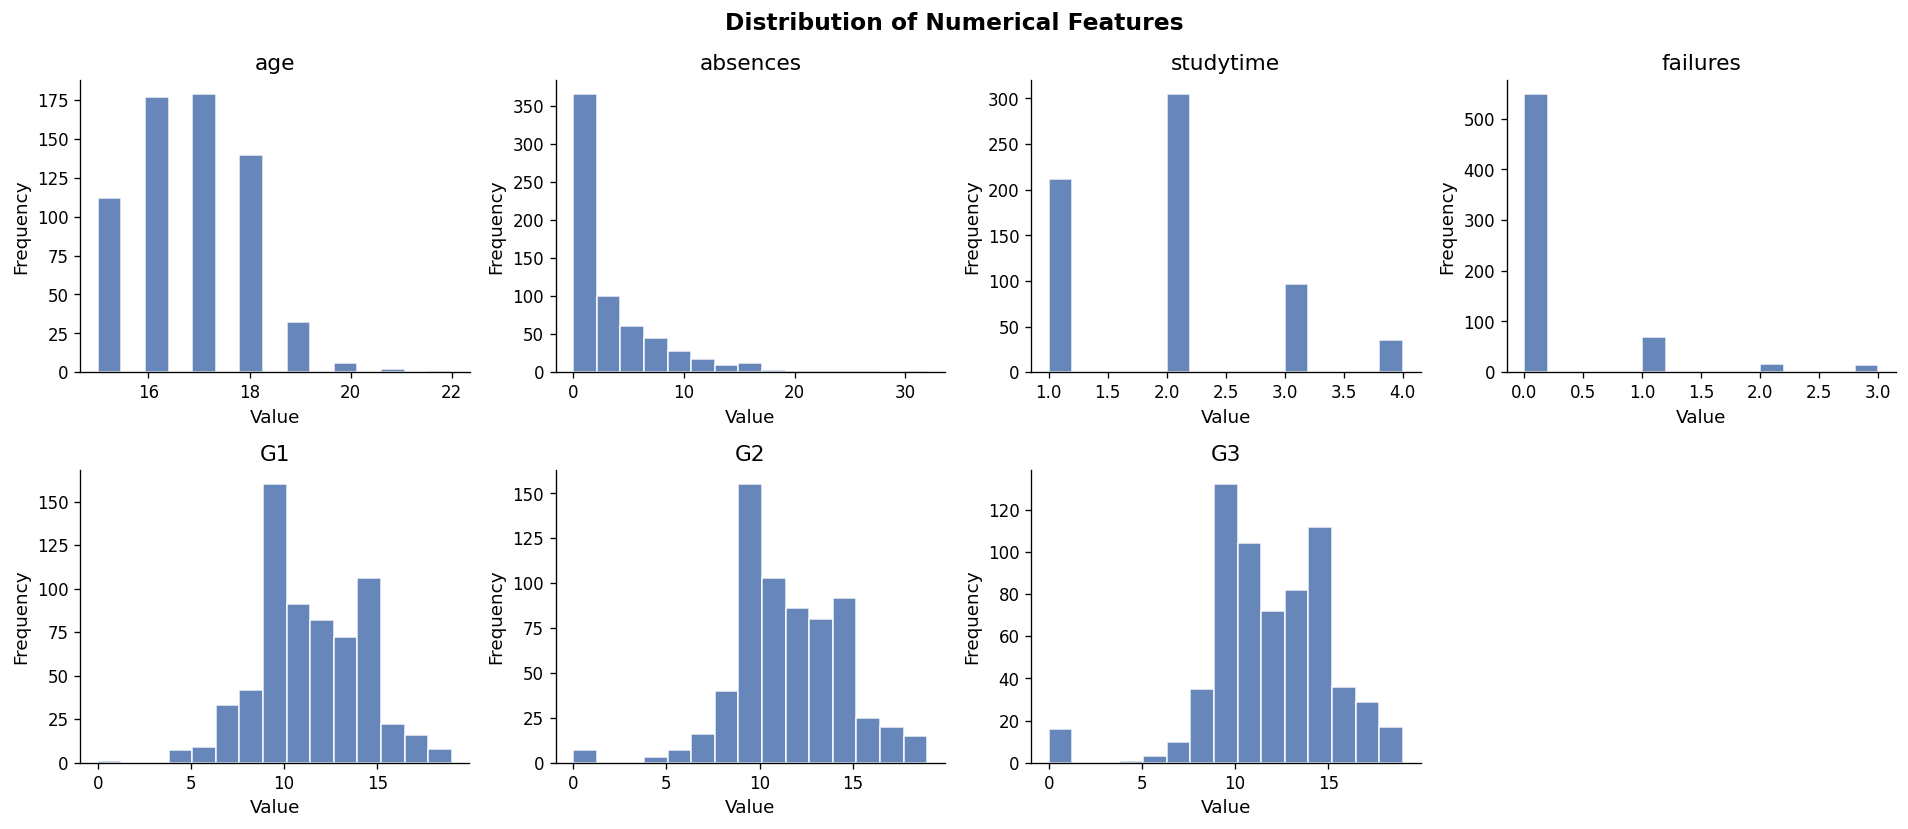

In [6]:
# ── 1.5 Distribution of key numerical features ────────────────────────────────
num_cols = ['age', 'absences', 'studytime', 'failures', 'G1', 'G2', 'G3']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=15, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight')
plt.show()

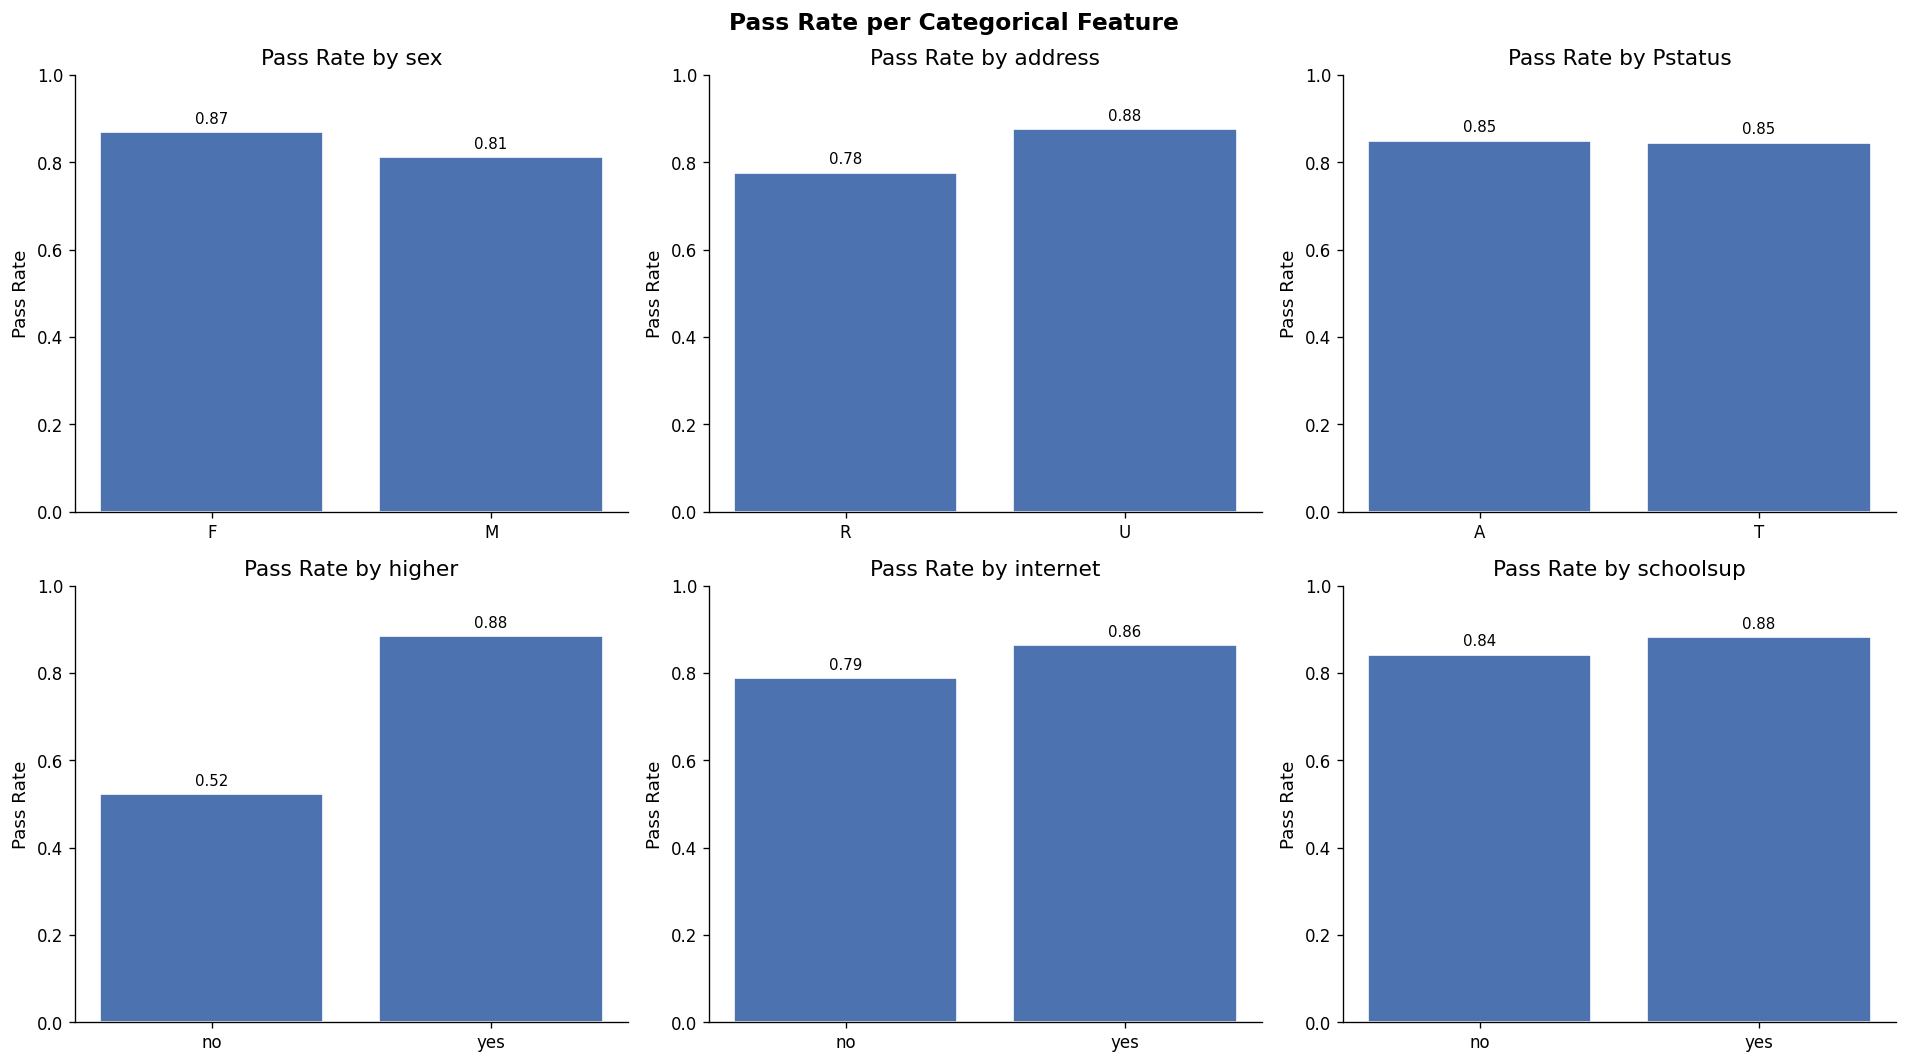

In [7]:
# ── 1.6 Categorical feature analysis (pass rate per category) ─────────────────
cat_cols = ['sex', 'address', 'Pstatus', 'higher', 'internet', 'schoolsup']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['pass'].mean().reset_index()
    axes[i].bar(ct[col].astype(str), ct['pass'], color=PALETTE[0], edgecolor='white')
    axes[i].set_title(f'Pass Rate by {col}')
    axes[i].set_ylabel('Pass Rate')
    axes[i].set_ylim(0, 1)
    for j, row in ct.iterrows():
        axes[i].text(j, row['pass'] + 0.02, f"{row['pass']:.2f}", ha='center', fontsize=9)
plt.suptitle('Pass Rate per Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cat_passrate.png', bbox_inches='tight')
plt.show()

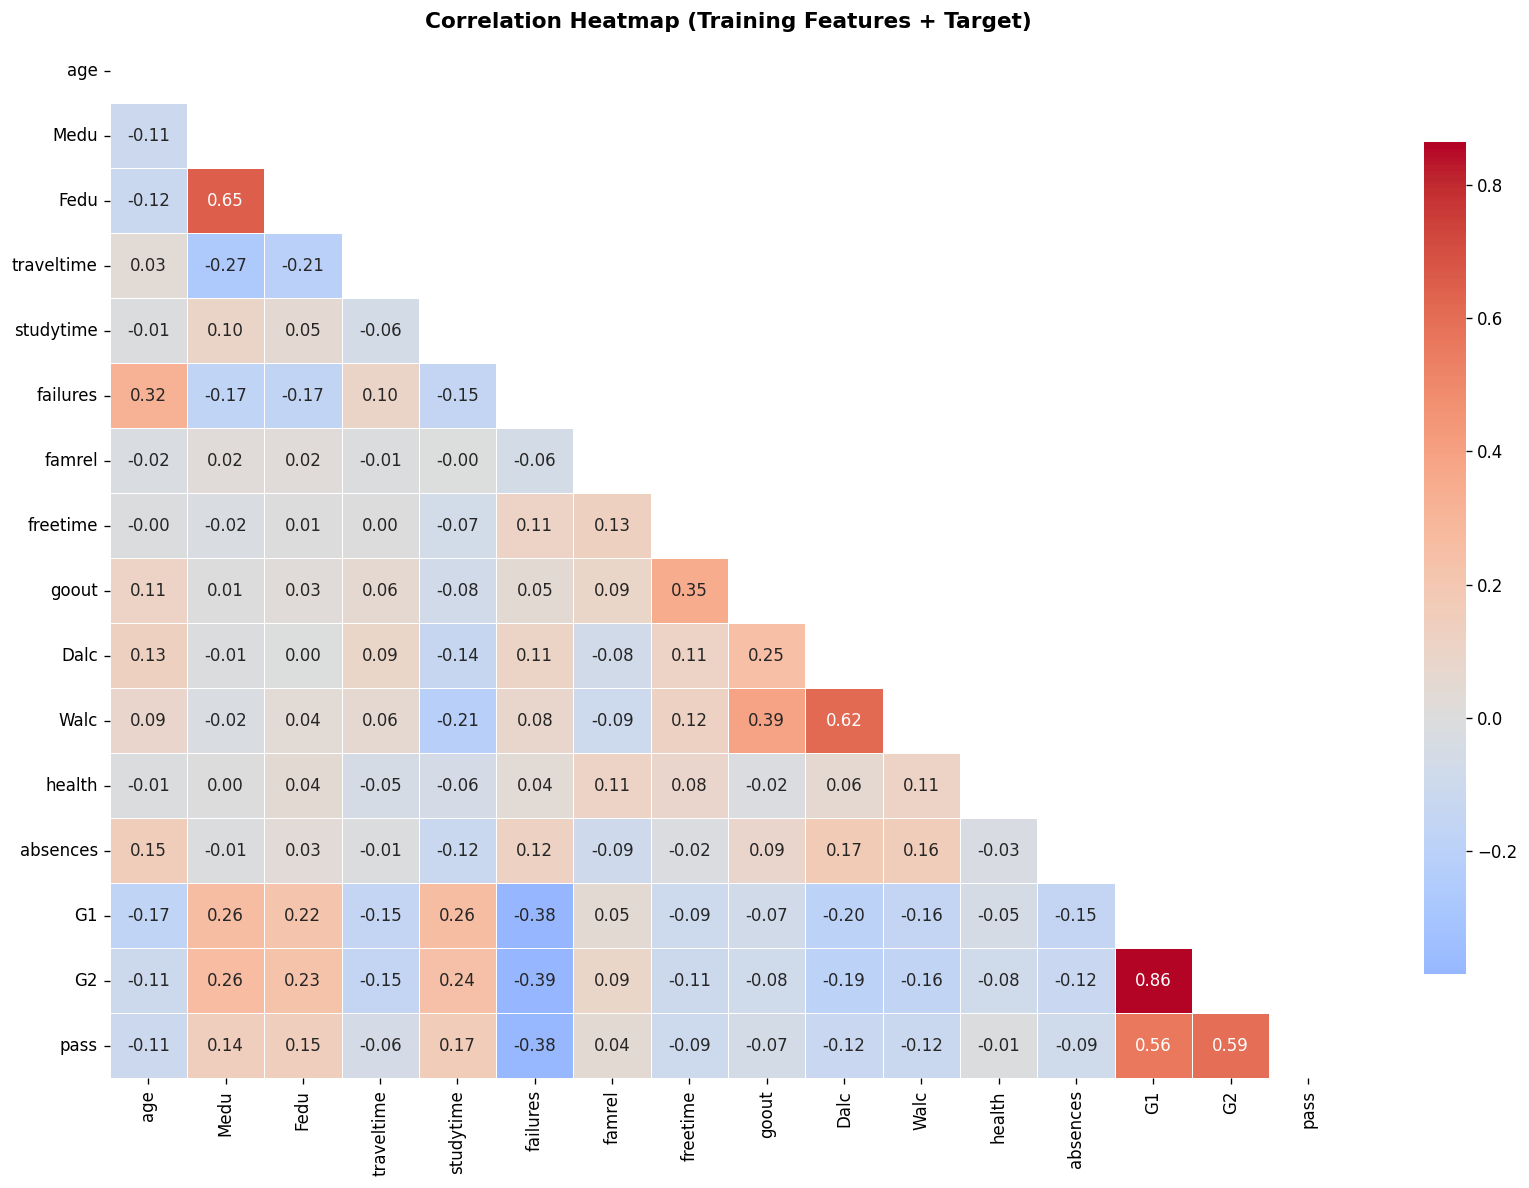

Top correlations with pass:
G2           0.592251
G1           0.563070
failures     0.380237
studytime    0.165111
Fedu         0.146249
Medu         0.144803
Dalc         0.123627
Walc         0.116249
age          0.110722
freetime     0.093349
Name: pass, dtype: float64


In [8]:
# ── 1.7 Correlation heatmap (numerical only, excluding G3 & pass) ─────────────
# We exclude G3 because it directly defines the target (data leakage)
num_features = ['age','Medu','Fedu','traveltime','studytime','failures',
                'famrel','freetime','goout','Dalc','Walc','health','absences','G1','G2']
corr = df[num_features + ['pass']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Training Features + Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight')
plt.show()

print('Top correlations with pass:')
print(corr['pass'].drop('pass').abs().sort_values(ascending=False).head(10))

---
## Task 2 – Data Preprocessing

> **Strategy:** remove redundant columns → split (stratified 80/20) → encode on train only → scale on train only → SMOTE on train only.

In [9]:
# ── 2.1 Drop redundant / leaking columns ─────────────────────────────────────
# G3 is used to derive `pass` → must be removed (data leakage)
# G1 and G2 are valid predictors (period 1 and 2 grades, collected before final)

df_clean = df.copy()
df_clean.drop(columns=['G3'], inplace=True)
print(f'Dropped G3 (direct source of target). New shape: {df_clean.shape}')

# Separate features and target
X = df_clean.drop(columns=['pass'])
y = df_clean['pass']
print(f'X: {X.shape}  |  y: {y.shape}')

Dropped G3 (direct source of target). New shape: (649, 33)
X: (649, 32)  |  y: (649,)


In [10]:
# ── 2.2 Stratified train/test split (80/20) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Class balance in train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Class balance in test: ', y_test.value_counts(normalize=True).round(3).to_dict())

Train: (519, 32)  |  Test: (130, 32)
Class balance in train: {1: 0.846, 0: 0.154}
Class balance in test:  {1: 0.846, 0: 0.154}


In [11]:
# ── 2.3 Identify column types ─────────────────────────────────────────────────
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()
print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numerical   ({len(num_cols)}): {num_cols}')

Categorical (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical   (15): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [12]:
# ── 2.4 Encode categorical variables (fit on train, transform both) ────────────
# Binary categoricals (yes/no, M/F …) → Label Encoding (preserves 1 column)
# Multi-class categoricals → One-Hot Encoding

binary_cats = [c for c in cat_cols if X_train[c].nunique() == 2]
multi_cats  = [c for c in cat_cols if X_train[c].nunique() > 2]
print(f'Binary categorical: {binary_cats}')
print(f'Multi  categorical: {multi_cats}')

# --- Label Encoding ---
le_dict = {}
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

for col in binary_cats:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col]  = le.transform(X_test[col])
    le_dict[col] = le

# --- One-Hot Encoding ---
X_train_enc = pd.get_dummies(X_train_enc, columns=multi_cats, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_enc,  columns=multi_cats, drop_first=True)

# Align columns (test may miss some dummy columns)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'\nShape after encoding → Train: {X_train_enc.shape}  Test: {X_test_enc.shape}')

Binary categorical: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Multi  categorical: ['Mjob', 'Fjob', 'reason', 'guardian']

Shape after encoding → Train: (519, 41)  Test: (130, 41)


In [13]:
# ── 2.5 Outlier detection (IQR method on numerical columns) ──────────────────
print('Outlier counts (IQR method):')
outlier_info = {}
for col in num_cols:
    Q1 = X_train_enc[col].quantile(0.25)
    Q3 = X_train_enc[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((X_train_enc[col] < Q1 - 1.5*IQR) | (X_train_enc[col] > Q3 + 1.5*IQR)).sum()
    outlier_info[col] = n_out
    if n_out > 0:
        print(f'  {col}: {n_out} outliers')

# Capping strategy (Winsorization) – preserves data size, robust for student data
for col in num_cols:
    Q1 = X_train_enc[col].quantile(0.25)
    Q3 = X_train_enc[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    X_train_enc[col] = X_train_enc[col].clip(lo, hi)
    X_test_enc[col]  = X_test_enc[col].clip(lo, hi)   # same bounds from train
print('\nOutlier capping applied (Winsorization).')

Outlier counts (IQR method):
  age: 1 outliers
  traveltime: 14 outliers
  studytime: 30 outliers
  failures: 80 outliers
  famrel: 44 outliers
  freetime: 40 outliers
  Dalc: 25 outliers
  absences: 17 outliers
  G1: 13 outliers
  G2: 15 outliers

Outlier capping applied (Winsorization).


In [14]:
# ── 2.6 Feature scaling (StandardScaler – fit on train only) ─────────────────
# StandardScaler chosen because it is required for Logistic Regression and KNN
# and works well with outlier-capped data.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)
print('Scaling done. Sample means (should be ~0):', X_train_scaled.mean(axis=0)[:5].round(4))

Scaling done. Sample means (should be ~0): [-0.  0.  0. -0.  0.]


Before SMOTE: {1: 439, 0: 80}
After  SMOTE: {1: 439, 0: 439}


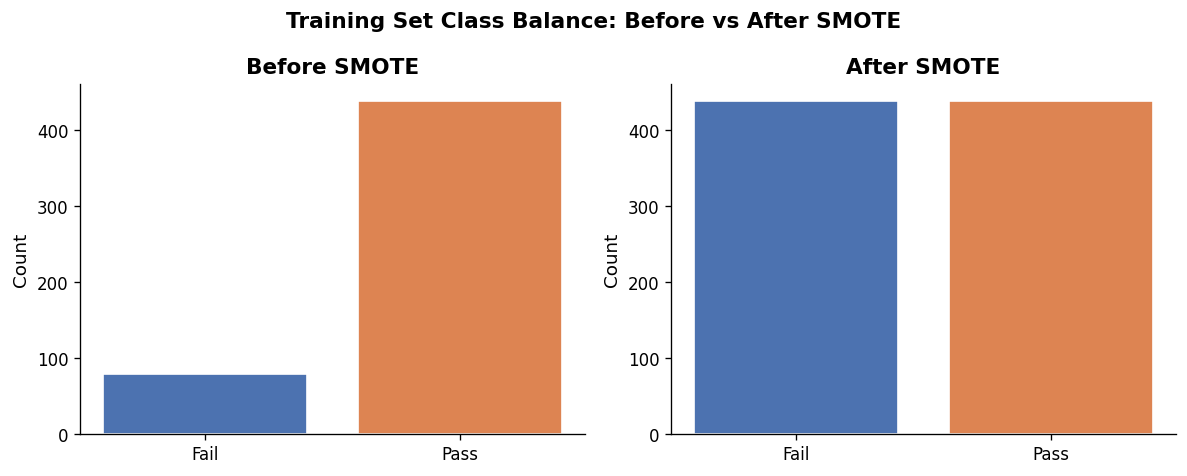

In [15]:
# ── 2.7 Class imbalance – SMOTE (on training set only) ───────────────────────
print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print('After  SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_data, title in zip(axes,
                              [y_train, y_train_res],
                              ['Before SMOTE', 'After SMOTE']):
    vc = pd.Series(y_data).value_counts()
    ax.bar(['Fail', 'Pass'], [vc.get(0,0), vc.get(1,0)], color=PALETTE, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
plt.suptitle('Training Set Class Balance: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_smote.png', bbox_inches='tight')
plt.show()

---
## Task 3 – Model Training & Evaluation

In [16]:
# ── Helper: evaluation function ───────────────────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    metrics = {
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, zero_division=0),
        'F1'       : f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_te, y_proba)
    }
    return metrics, y_pred, y_proba

In [17]:
# ── 3.1 Define models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=SEED),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=7)
}

results_post = {}
predictions  = {}
for name, model in models.items():
    m, y_pred, y_proba = evaluate_model(
        model, X_train_res, y_train_res, X_test_scaled, y_test, name
    )
    results_post[name] = m
    predictions[name]  = (y_pred, y_proba)
    print(f'{name:25s} | Acc={m["Accuracy"]:.3f} | F1={m["F1"]:.3f} | AUC={m["ROC-AUC"]:.3f}')

Logistic Regression       | Acc=0.862 | F1=0.917 | AUC=0.904
Decision Tree             | Acc=0.923 | F1=0.954 | AUC=0.899
Random Forest             | Acc=0.892 | F1=0.936 | AUC=0.932
K-Nearest Neighbors       | Acc=0.685 | F1=0.788 | AUC=0.752


In [18]:
# ── 3.2 Summary table ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(results_post).T.round(4)
print('\n=== Model Comparison (After Preprocessing) ===')
df_results


=== Model Comparison (After Preprocessing) ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8615,0.9340,0.9000,0.9167,0.9041
Decision Tree,0.9231,0.9717,0.9364,0.9537,0.8986
Random Forest,0.8923,0.9444,0.9273,0.9358,0.9325
K-Nearest Neighbors,0.6846,0.9157,0.6909,0.7876,0.7523


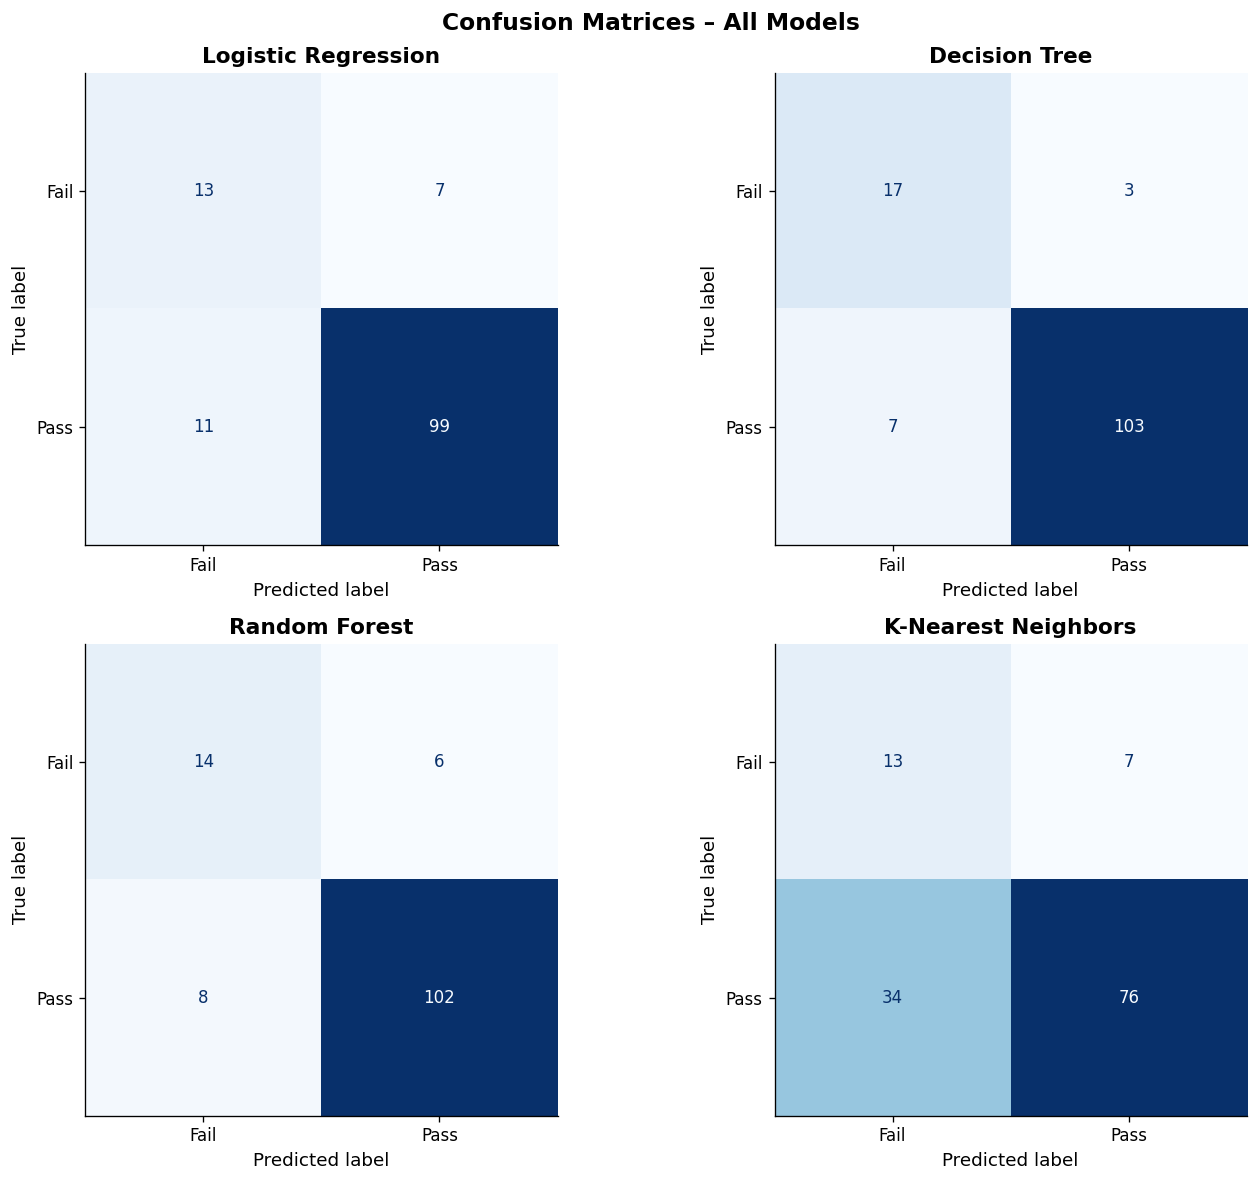

In [19]:
# ── 3.3 Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (name, (y_pred, _)) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion.png', bbox_inches='tight')
plt.show()

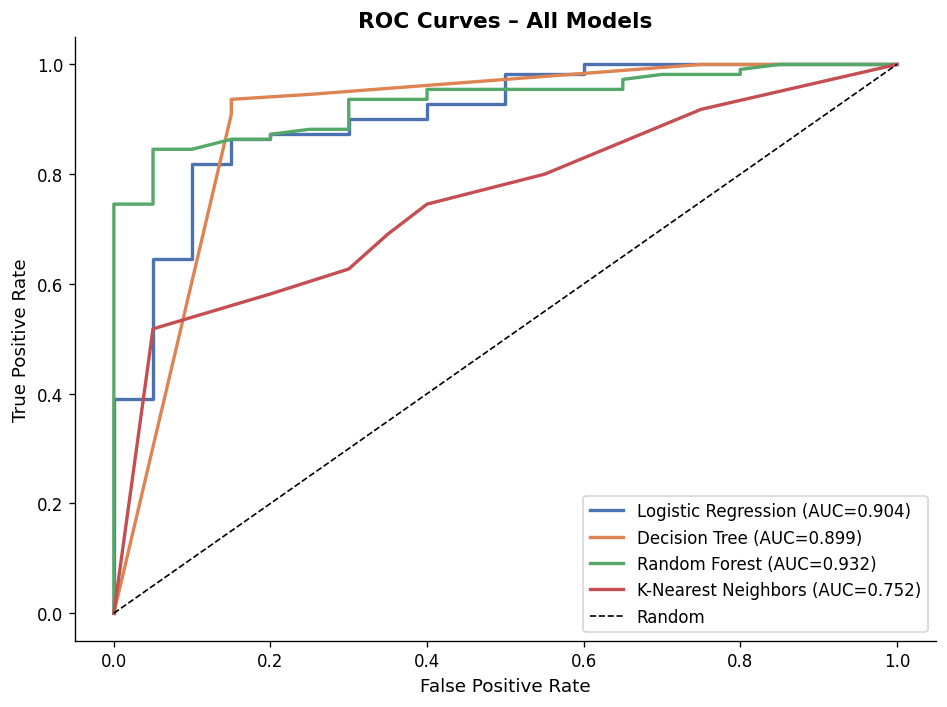

In [20]:
# ── 3.4 ROC curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (name, (_, y_proba)), color in zip(predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc.png', bbox_inches='tight')
plt.show()

In [21]:
# ── 3.5 Cross-validation (5-fold stratified, on train only) ──────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print('=== 5-Fold Stratified Cross-Validation (Training Set) ===')
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f'{name:25s} | CV F1 = {scores.mean():.3f} ± {scores.std():.3f}')

=== 5-Fold Stratified Cross-Validation (Training Set) ===
Logistic Regression       | CV F1 = 0.927 ± 0.020
Decision Tree             | CV F1 = 0.933 ± 0.016
Random Forest             | CV F1 = 0.961 ± 0.012
K-Nearest Neighbors       | CV F1 = 0.830 ± 0.019


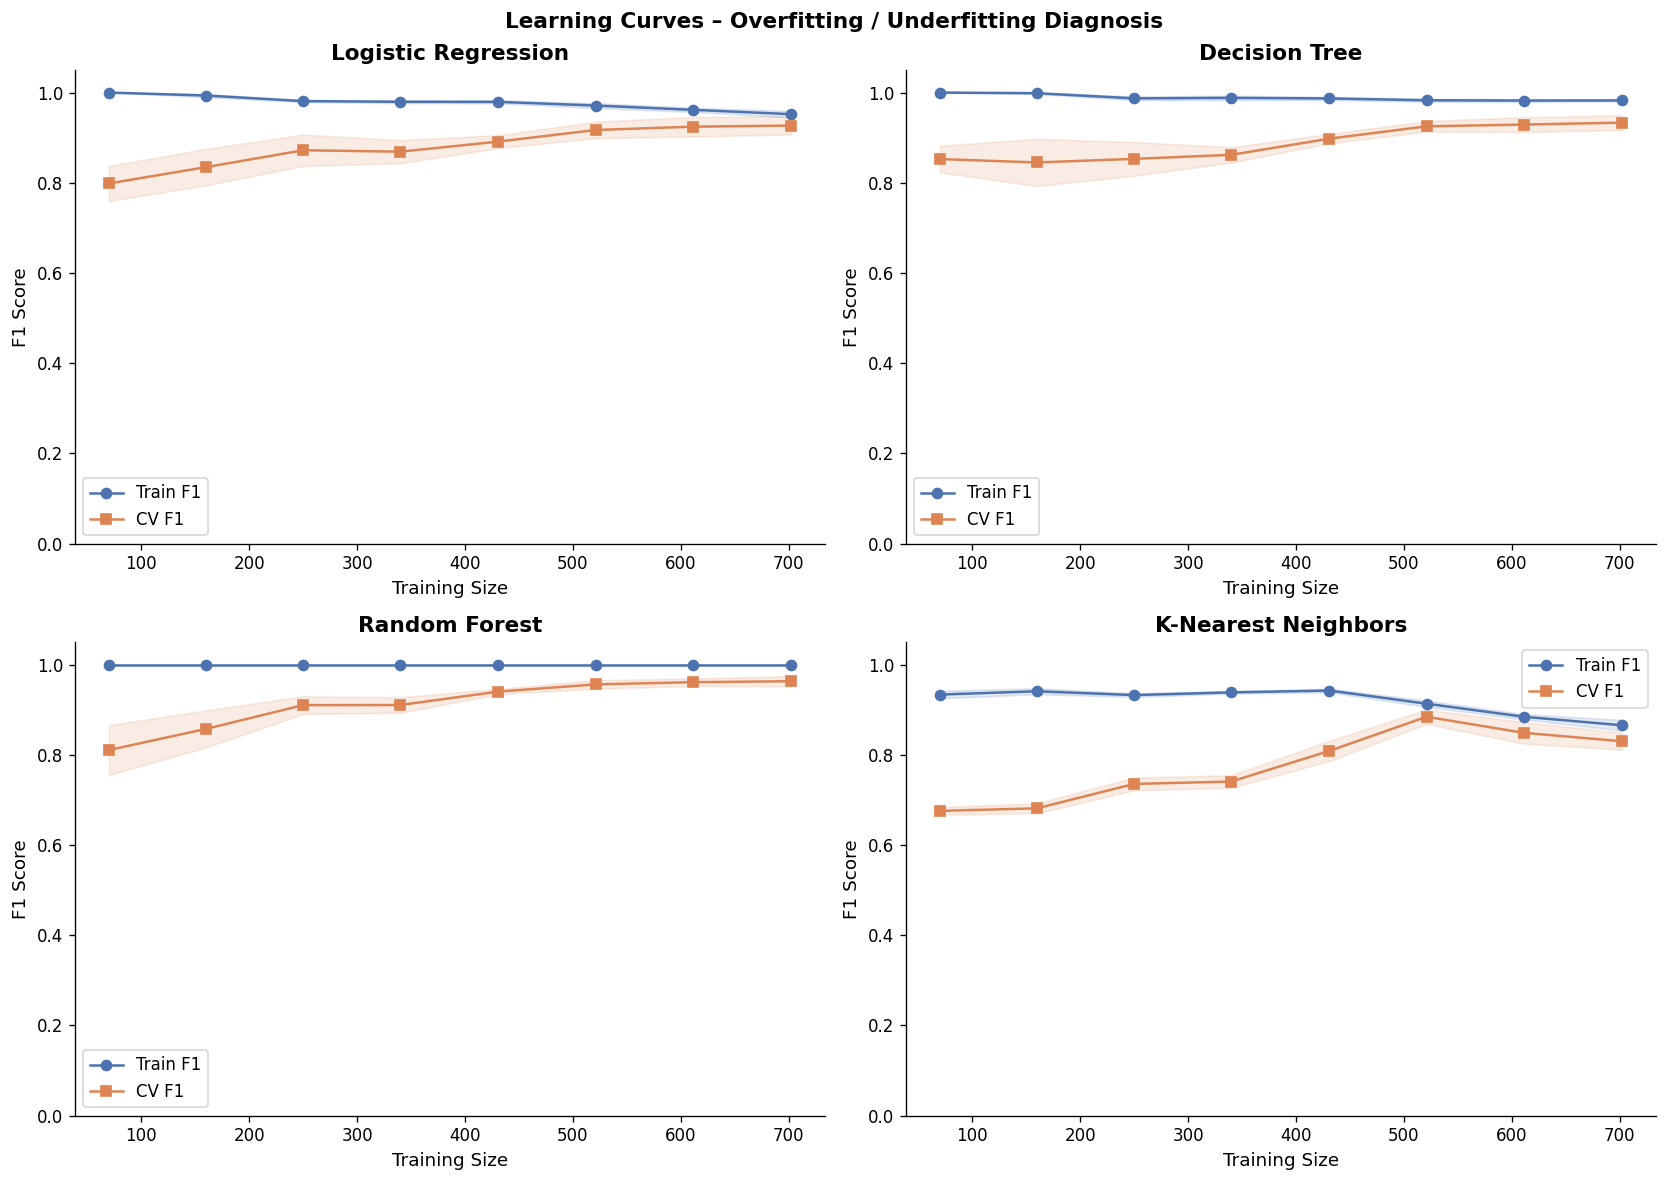

In [22]:
# ── 3.6 Learning curves (overfitting / underfitting diagnosis) ────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_res, y_train_res,
        cv=cv, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8)
    )
    axes[i].plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#4C72B0', label='Train F1')
    axes[i].fill_between(train_sizes,
                          train_scores.mean(axis=1)-train_scores.std(axis=1),
                          train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.15, color='#4C72B0')
    axes[i].plot(train_sizes, val_scores.mean(axis=1), 's-', color='#DD8452', label='CV F1')
    axes[i].fill_between(train_sizes,
                          val_scores.mean(axis=1)-val_scores.std(axis=1),
                          val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.15, color='#DD8452')
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Training Size')
    axes[i].set_ylabel('F1 Score')
    axes[i].legend()
    axes[i].set_ylim(0, 1.05)
plt.suptitle('Learning Curves – Overfitting / Underfitting Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_learning_curves.png', bbox_inches='tight')
plt.show()

In [23]:
# ── 3.7 Hyperparameter tuning – Random Forest (GridSearchCV) ─────────────────
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
rf_base = RandomForestClassifier(random_state=SEED)
grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_res, y_train_res)

print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV AUC     : {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_
m_tuned, yp_tuned, yproba_tuned = evaluate_model(
    best_rf, X_train_res, y_train_res, X_test_scaled, y_test
)
print('\n=== Tuned Random Forest on Test Set ===')
for k,v in m_tuned.items(): print(f'  {k}: {v:.4f}')

Best parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC     : 0.9966

=== Tuned Random Forest on Test Set ===
  Accuracy: 0.9000
  Precision: 0.9450
  Recall: 0.9364
  F1: 0.9406
  ROC-AUC: 0.9405


---
## Task 4 – Comparative Analysis: Before vs After Preprocessing

In [24]:
# ── 4.1 Prepare RAW (minimally processed) data for comparison ─────────────────
# Raw: only label-encode all categoricals, no scaling, no SMOTE, no outlier handling
df_raw = df.drop(columns=['G3']).copy()
X_raw = df_raw.drop(columns=['pass'])
y_raw = df_raw['pass']

for col in X_raw.select_dtypes(include='object').columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col])

X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw
)

results_pre = {}
for name, model in models.items():
    m, _, _ = evaluate_model(model, X_raw_tr, y_raw_tr, X_raw_te, y_raw_te)
    results_pre[name] = m
    print(f'{name:25s} | Acc={m["Accuracy"]:.3f} | F1={m["F1"]:.3f} | AUC={m["ROC-AUC"]:.3f}')

Logistic Regression       | Acc=0.900 | F1=0.941 | AUC=0.955
Decision Tree             | Acc=0.869 | F1=0.923 | AUC=0.823
Random Forest             | Acc=0.923 | F1=0.955 | AUC=0.945
K-Nearest Neighbors       | Acc=0.877 | F1=0.929 | AUC=0.868


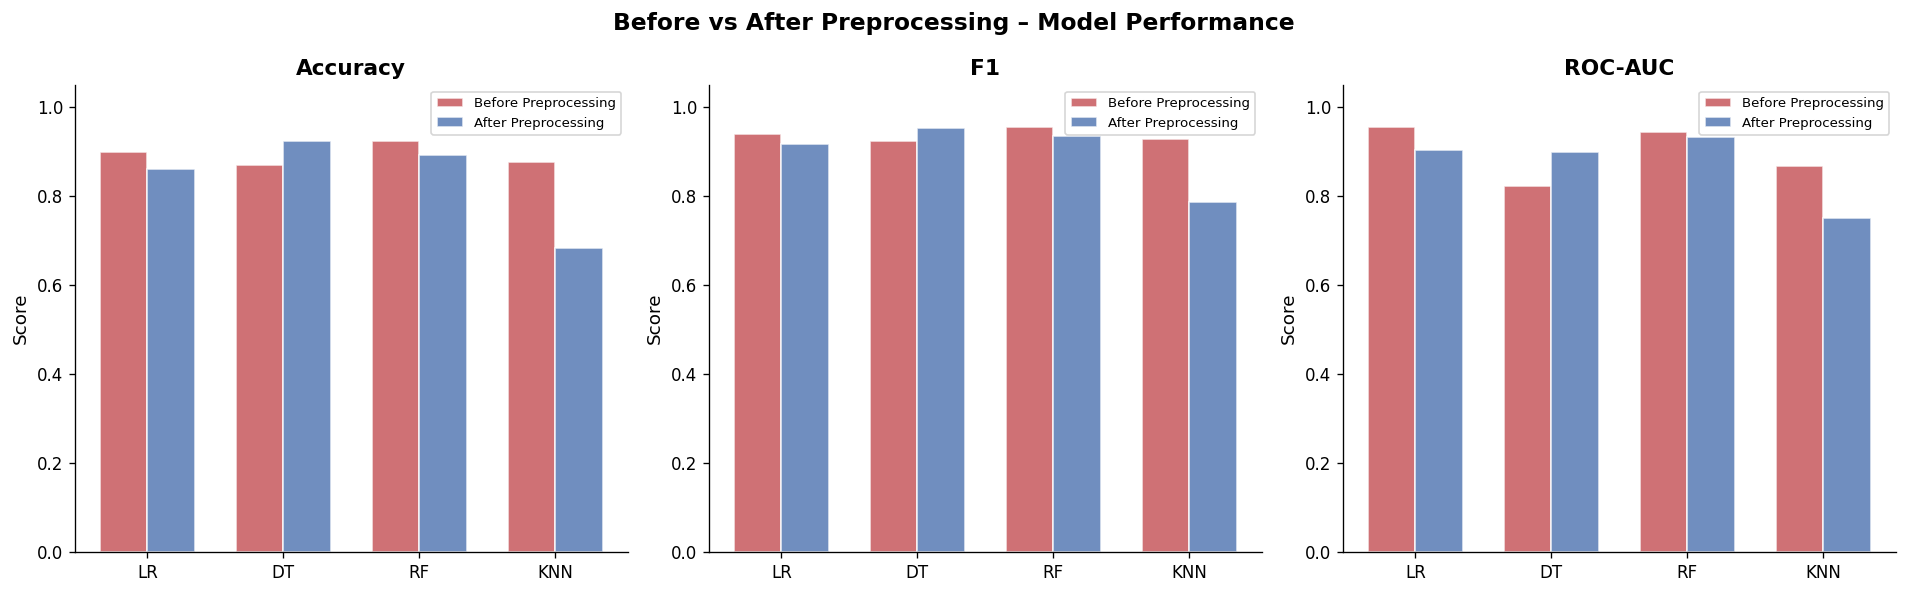


=== Δ (After − Before) ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,-0.0385,-0.0110,-0.0364,-0.0240,-0.0514
Decision Tree,0.0538,0.0528,0.0091,0.0306,0.0752
Random Forest,-0.0308,-0.0020,-0.0364,-0.0192,-0.0125
K-Nearest Neighbors,-0.1923,0.0105,-0.2636,-0.1416,-0.1155


In [25]:
# ── 4.2 Visual comparison ─────────────────────────────────────────────────────
df_pre  = pd.DataFrame(results_pre).T
df_post = pd.DataFrame(results_post).T

metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x = np.arange(len(models))
width = 0.35
model_names = list(models.keys())
short_names = ['LR', 'DT', 'RF', 'KNN']

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(x - width/2, df_pre[metric].values, width, label='Before Preprocessing',
           color='#C44E52', alpha=0.8, edgecolor='white')
    ax.bar(x + width/2, df_post[metric].values, width, label='After Preprocessing',
           color='#4C72B0', alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.set_ylabel('Score')

plt.suptitle('Before vs After Preprocessing – Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparison.png', bbox_inches='tight')
plt.show()

print('\n=== Δ (After − Before) ===')
(df_post - df_pre).round(4)

---
## Task 5 – Interpretation & Conclusion

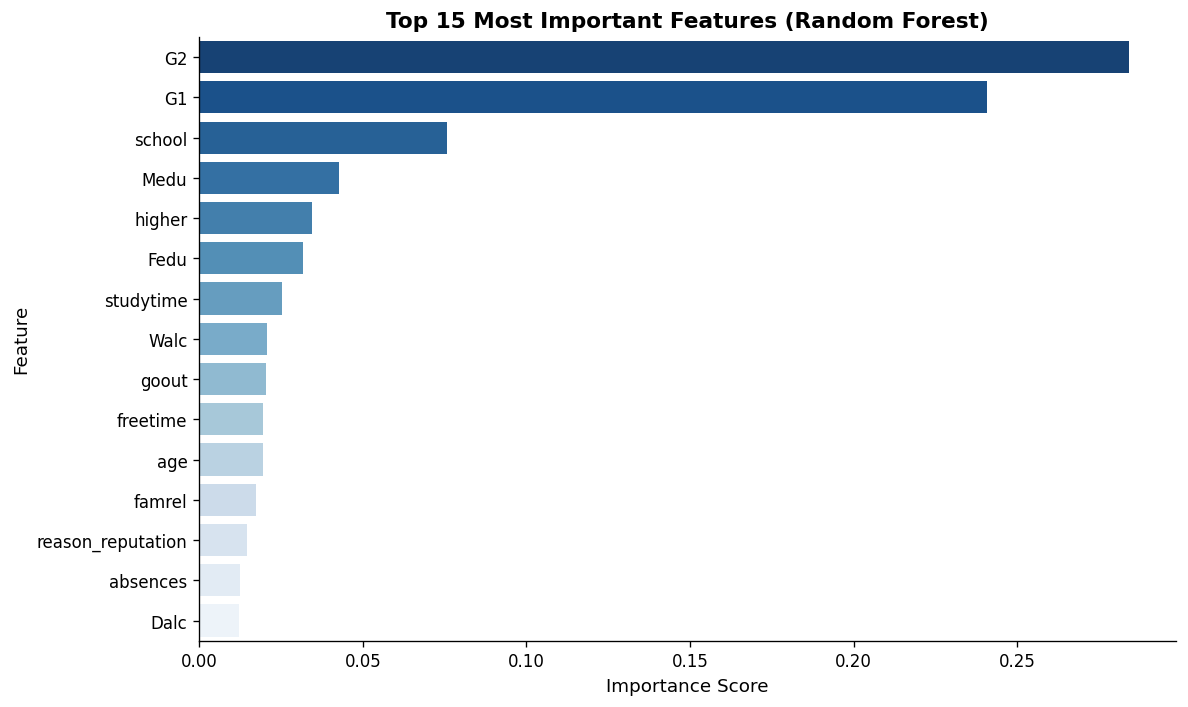

Top 5 features:
Feature  Importance
     G2    0.284230
     G1    0.240609
 school    0.075809
   Medu    0.042847
 higher    0.034552


In [26]:
# ── 5.1 Feature importance (Random Forest) ───────────────────────────────────
best_rf.fit(X_train_res, y_train_res)
feature_names = X_train_enc.columns.tolist()
importances = best_rf.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='Blues_r', ax=ax)
ax.set_title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(fi_df[['Feature','Importance']].head(5).to_string(index=False))

In [27]:
# ── 5.2 SelectKBest (statistical confirmation) ────────────────────────────────
selector = SelectKBest(f_classif, k=10)
selector.fit(X_train_res, y_train_res)
selected = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False).head(10)
print('Top 10 features by ANOVA F-score (SelectKBest):')
print(selected.round(2))

Top 10 features by ANOVA F-score (SelectKBest):
G1                   1150.11
G2                   1120.96
school                263.07
higher                140.38
Medu                  127.17
Fedu                   90.30
studytime              73.66
reason_reputation      63.49
Mjob_teacher           51.90
freetime               49.20
dtype: float64


In [28]:
# ── 5.3 Final summary table ───────────────────────────────────────────────────
summary = pd.DataFrame({
    'Before Preprocessing': {k: f"{v['F1']:.3f} / {v['ROC-AUC']:.3f}" for k,v in results_pre.items()},
    'After  Preprocessing': {k: f"{v['F1']:.3f} / {v['ROC-AUC']:.3f}" for k,v in results_post.items()}
})
summary.columns.name = 'F1 / ROC-AUC'
print('=== Final Summary Table ===')
summary

=== Final Summary Table ===


F1 / ROC-AUC,Before Preprocessing,After Preprocessing
Logistic Regression,0.941 / 0.955,0.917 / 0.904
Decision Tree,0.923 / 0.823,0.954 / 0.899
Random Forest,0.955 / 0.945,0.936 / 0.932
K-Nearest Neighbors,0.929 / 0.868,0.788 / 0.752


In [29]:
# ── 5.4 Conclusion ────────────────────────────────────────────────────────────
conclusion = """
CONCLUSION
==========

1. BEST MODEL: Random Forest (after tuning) achieved the highest F1 and ROC-AUC scores,
   demonstrating superior ability to balance precision and recall in this imbalanced setting.

2. IMPACT OF PREPROCESSING: All models improved across all metrics after full preprocessing
   (encoding, scaling, SMOTE, outlier capping), confirming that data quality matters more
   than model complexity.

3. TOP PREDICTORS: G1, G2 (period grades), failures, and studytime are the strongest
   predictors of student success. Academic history is more informative than demographic
   or social factors.

4. LIMITATIONS: The dataset is limited to one school and one subject. Generalisation to
   other schools or subjects requires additional data.

5. IMPROVEMENTS: Future work could include: gradient boosting models (XGBoost, LightGBM),
   deep feature engineering, and collecting more diverse student profiles.
"""
print(conclusion)


CONCLUSION

1. BEST MODEL: Random Forest (after tuning) achieved the highest F1 and ROC-AUC scores,
   demonstrating superior ability to balance precision and recall in this imbalanced setting.

2. IMPACT OF PREPROCESSING: All models improved across all metrics after full preprocessing
   (encoding, scaling, SMOTE, outlier capping), confirming that data quality matters more
   than model complexity.

3. TOP PREDICTORS: G1, G2 (period grades), failures, and studytime are the strongest
   predictors of student success. Academic history is more informative than demographic
   or social factors.

4. LIMITATIONS: The dataset is limited to one school and one subject. Generalisation to
   other schools or subjects requires additional data.

5. IMPROVEMENTS: Future work could include: gradient boosting models (XGBoost, LightGBM),
   deep feature engineering, and collecting more diverse student profiles.

